In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import Sequential, layers, Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, LayerNormalization, GroupNormalization
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasRegressor
import torch
import torch.nn as nn
import torch.optim as optim
from skorch import NeuralNetRegressor
from skorch.callbacks import EarlyStopping
from skorch import NeuralNetClassifier

In [2]:
df = pd.read_csv('C:/Users/ASUS/my_projects/archive3/diamonds.csv')
df = pd.get_dummies(df, drop_first=True)

for col in df.select_dtypes(include=['number']).columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

X = df.drop(columns=['price']).values
y = df['price'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
df

,carat,depth,table,x,y,z,price,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,3.95,3.98,2.43,326,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,3.89,3.84,2.31,326,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,4.05,4.07,2.31,327,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,4.20,4.23,2.63,334,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,4.34,4.35,2.75,335,True,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,5.75,5.76,3.50,2757,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.1,55.0,5.69,5.75,3.61,2757,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.8,60.0,5.66,5.68,3.56,2757,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.0,58.0,6.15,6.12,3.74,2757,False,False,True,...,True,False,False,False,False,True,False,False,False,False


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score

def build_model_bn(input_shape, neurons1=128, neurons2=64, dropout_rate=0.2):
    model = Sequential([
        Dense(neurons1, input_shape=(input_shape,)),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(dropout_rate),
        
        Dense(neurons2),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(dropout_rate),
        
        Dense(32),
        BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_bn = build_model_bn(X_train.shape[1])
history_bn = model_bn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

y_pred_bn = model_bn.predict(X_test).flatten()
mae_bn = mean_absolute_error(y_test, y_pred_bn)
r2_bn = r2_score(y_test, y_pred_bn)
print(f"BatchNormalization -> MAE: {mae_bn:.2f}, R²: {r2_bn:.4f}")


c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 30915442.0000 - mae: 3909.2407 - val_loss: 30405962.0000 - val_mae: 3887.9675
Epoch 2/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 28456734.0000 - mae: 3758.3772 - val_loss: 26767636.0000 - val_mae: 3666.5684
Epoch 3/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 24424760.0000 - mae: 3486.3777 - val_loss: 22519686.0000 - val_mae: 3378.8542
Epoch 4/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 19744966.0000 - mae: 3129.6084 - val_loss: 17721344.0000 - val_mae: 3009.1602
Epoch 5/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 14957275.0000 - mae: 2709.7021 - val_loss: 12542552.0000 - val_mae: 2558.9795
Epoch 6/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 10518671.0000 - mae: 2246.0435 - val_loss: 8075483.0000 - val_mae: 2084.2747
Epoch 7/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 6844901.5000 - mae: 1763.2715 - val_loss: 4367152.5000 - val_mae: 1477.2478
Epoch 8/100
1079

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score

def build_model_lr(input_shape, neurons1=128, neurons2=64, dropout_rate=0.2):
    model = Sequential([
        Dense(neurons1, input_shape=(input_shape,)),
        LayerNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(dropout_rate),
        
        Dense(neurons2),
        LayerNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(dropout_rate),
        
        Dense(32),
        LayerNormalization(),
        tf.keras.layers.Activation('relu'),
        
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_lr = build_model_lr(X_train.shape[1])
history_lr = model_lr.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

y_pred_lr = model_lr.predict(X_test).flatten()
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"GroupNormalization -> MAE: {mae_lr:.2f}, R²: {r2_lr:.4f}")


Epoch 1/100


c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1079/1079 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 31074966.0000 - mae: 3898.0710 - val_loss: 31107740.0000 - val_mae: 3875.7158
Epoch 2/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 29984940.0000 - mae: 3755.5681 - val_loss: 29635428.0000 - val_mae: 3680.8884
Epoch 3/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 28262140.0000 - mae: 3519.3291 - val_loss: 27678436.0000 - val_mae: 3412.9211
Epoch 4/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 26184712.0000 - mae: 3255.1765 - val_loss: 25481764.0000 - val_mae: 3172.3918
Epoch 5/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 23959720.0000 - mae: 3025.6970 - val_loss: 23136972.0000 - val_mae: 2880.9341
Epoch 6/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 21571230.0000 - mae: 2714.3125 - val_loss: 20711970.0000 - val_mae: 2602.4583
Epoch 7/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 19191360.0000 - mae: 2447.1995 - val_loss: 18321208.0000 - val_mae: 2337.7844
Epoch 8/100
1079/1079 ━━━

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GroupNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score

def build_model_gn(input_shape, neurons1=128, neurons2=64, dropout_rate=0.2):
    model = Sequential([
        Dense(neurons1, input_shape=(input_shape,)),
        GroupNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(dropout_rate),
        
        Dense(neurons2),
        GroupNormalization(),
        tf.keras.layers.Activation('relu'),
        Dropout(dropout_rate),
        
        Dense(32),
        GroupNormalization(),
        tf.keras.layers.Activation('relu'),
        
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_gn = build_model_gn(X_train.shape[1])
history_gn = model_gn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

y_pred_gn = model_gn.predict(X_test).flatten()
mae_gn = mean_absolute_error(y_test, y_pred_gn)
r2_gn = r2_score(y_test, y_pred_gn)
print(f"InstanceNormalization -> MAE: {mae_gn:.2f}, R²: {r2_gn:.4f}")


Epoch 1/100


c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 31344862.0000 - mae: 3932.8079 - val_loss: 31792220.0000 - val_mae: 3963.0461
Epoch 2/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 31336498.0000 - mae: 3931.7490 - val_loss: 31783784.0000 - val_mae: 3961.9832
Epoch 3/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 31328144.0000 - mae: 3930.6907 - val_loss: 31775338.0000 - val_mae: 3960.9209
Epoch 4/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 31319790.0000 - mae: 3929.6216 - val_loss: 31766938.0000 - val_mae: 3959.8582
Epoch 5/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31311430.0000 - mae: 3928.5605 - val_loss: 31758546.0000 - val_mae: 3958.7964
Epoch 6/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31303116.0000 - mae: 3927.4988 - val_loss: 31750166.0000 - val_mae: 3957.7361
Epoch 7/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31294806.0000 - mae: 3926.4412 - val_loss: 31741722.0000 - val_mae: 3956.6716
Epoch 8/100
1079/1079 ━━━

In [6]:
df = pd.read_csv('C:/Users/ASUS/my_projects/archive3/diamonds.csv')
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
categorical_cols = ['cut', 'color', 'clarity']
numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

inputs = {}
preprocessed_features = []

for col in numeric_cols:
    inp = layers.Input(shape=(1,), name=col)
    inputs[col] = inp
    norm_layer = layers.Normalization(axis=None)
    norm_layer.adapt(X_train[col].values.reshape(-1, 1))
    normalized = norm_layer(inp)
    preprocessed_features.append(normalized)

for col in categorical_cols:
    inp = layers.Input(shape=(1,), name=col, dtype=tf.string)
    inputs[col] = inp
    lookup = layers.StringLookup(output_mode='one_hot')
    lookup.adapt(X_train[col].values)
    encoded = lookup(inp)
    preprocessed_features.append(encoded)

In [8]:
concatenated = layers.Concatenate()(preprocessed_features)

x = layers.Dense(128, activation='relu')(concatenated)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1)(x)

model = Model(inputs=inputs, outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [9]:
train_dict = {col: X_train[col].values for col in X_train.columns}
test_dict = {col: X_test[col].values for col in X_test.columns}

history = model.fit(
    train_dict, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

y_pred = model.predict(test_dict).flatten()
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Pipeline model -> MAE: {mae:.2f}, R²: {r2:.4f}")

Epoch 1/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 5579753.5000 - mae: 1170.2605 - val_loss: 975740.6250 - val_mae: 567.5510
Epoch 2/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1274494.0000 - mae: 608.0552 - val_loss: 753603.2500 - val_mae: 477.0506
Epoch 3/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1107485.2500 - mae: 549.6925 - val_loss: 621963.4375 - val_mae: 423.9826
Epoch 4/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 981011.7500 - mae: 514.5402 - val_loss: 556357.1250 - val_mae: 394.6363
Epoch 5/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 942300.3125 - mae: 506.7514 - val_loss: 573898.8125 - val_mae: 400.1723
Epoch 6/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 848896.0000 - mae: 491.5078 - val_loss: 499120.9375 - val_mae: 371.4493
Epoch 7/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 821579.1875 - mae: 485.4380 - val_loss: 497214.0625 - val_mae: 376.3139
Epoch 8/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/s

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [11]:
torch.manual_seed(42)
np.random.seed(42)

df = pd.read_csv('archive3/diamonds.csv')

numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_cols = ['cut', 'color', 'clarity']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('price', axis=1)
y = df['price']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)
y_train_float = y_train.values.astype(np.float32).reshape(-1, 1)
y_test_float = y_test.values.astype(np.float32).reshape(-1, 1)

X_train_t = torch.tensor(X_train_scaled)
y_train_t = torch.tensor(y_train_float)
X_test_t = torch.tensor(X_test_scaled)
y_test_t = torch.tensor(y_test_float)

print(f"Train: {X_train_t.shape}, Test: {X_test_t.shape}")

Train: torch.Size([43152, 9]), Test: torch.Size([10788, 9])


In [13]:
class DiamondModelBN(nn.Module):
    def __init__(self, input_dim, neurons1=128, neurons2=64, dropout_rate=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, neurons1)
        self.bn1 = nn.BatchNorm1d(neurons1)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(neurons1, neurons2)
        self.bn2 = nn.BatchNorm1d(neurons2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc3 = nn.Linear(neurons2, 32)
        self.bn3 = nn.BatchNorm1d(32)
        
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)
        return x

In [14]:
class DiamondModelLN(nn.Module):
    def __init__(self, input_dim, neurons1=128, neurons2=64, dropout_rate=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, neurons1)
        self.ln1 = nn.LayerNorm(neurons1)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(neurons1, neurons2)
        self.ln2 = nn.LayerNorm(neurons2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc3 = nn.Linear(neurons2, 32)
        self.ln3 = nn.LayerNorm(32)
        
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.ln1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.ln2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.relu(self.ln3(self.fc3(x)))
        x = self.fc4(x)
        return x

In [15]:
class DiamondModelGN(nn.Module):
    def __init__(self, input_dim, neurons1=128, neurons2=64, dropout_rate=0.2, groups=4):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, neurons1)
        self.gn1 = nn.GroupNorm(groups, neurons1)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(neurons1, neurons2)
        self.gn2 = nn.GroupNorm(groups, neurons2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc3 = nn.Linear(neurons2, 32)
        self.gn3 = nn.GroupNorm(groups, 32)
        
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.gn1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.gn2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.relu(self.gn3(self.fc3(x)))
        x = self.fc4(x)
        return x

In [16]:
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, patience=10):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    val_maes = []
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        # Train
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))
        
        # Validation
        model.eval()
        val_loss = 0
        val_mae = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                val_mae += torch.abs(outputs - batch_y).mean().item()
        val_losses.append(val_loss / len(val_loader))
        val_maes.append(val_mae / len(val_loader))

        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    return train_losses, val_losses, val_maes, model

In [17]:
batch_size = 32
input_dim = X_train_t.shape[1]

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train_t, y_train_t, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train_new, y_train_new)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

models = {
    'BatchNorm': DiamondModelBN(input_dim),
    'LayerNorm': DiamondModelLN(input_dim),
    'GroupNorm': DiamondModelGN(input_dim, groups=4)
}

histories = {}
final_maes = {}
final_r2s = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    train_losses, val_losses, val_maes, trained_model = train_model(
        model, train_loader, val_loader, epochs=100, lr=0.001, patience=10
    )
    histories[name] = (train_losses, val_losses, val_maes)

    trained_model.eval()
    preds = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            preds.append(trained_model(batch_X).numpy())
    y_pred = np.concatenate(preds).flatten()
    y_true = y_test_t.numpy().flatten()
    
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    final_maes[name] = mae
    final_r2s[name] = r2
    print(f"{name} -> MAE: {mae:.2f}, R²: {r2:.4f}")


--- Training BatchNorm ---


c:\Users\ASUS\anaconda3\Lib\site-packages\torch\autograd\graph.py:979: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Early stopping at epoch 40
BatchNorm -> MAE: 713.97, R²: 0.8859

--- Training LayerNorm ---
Early stopping at epoch 47
LayerNorm -> MAE: 323.03, R²: 0.9784

--- Training GroupNorm ---
Early stopping at epoch 69
GroupNorm -> MAE: 311.18, R²: 0.9795


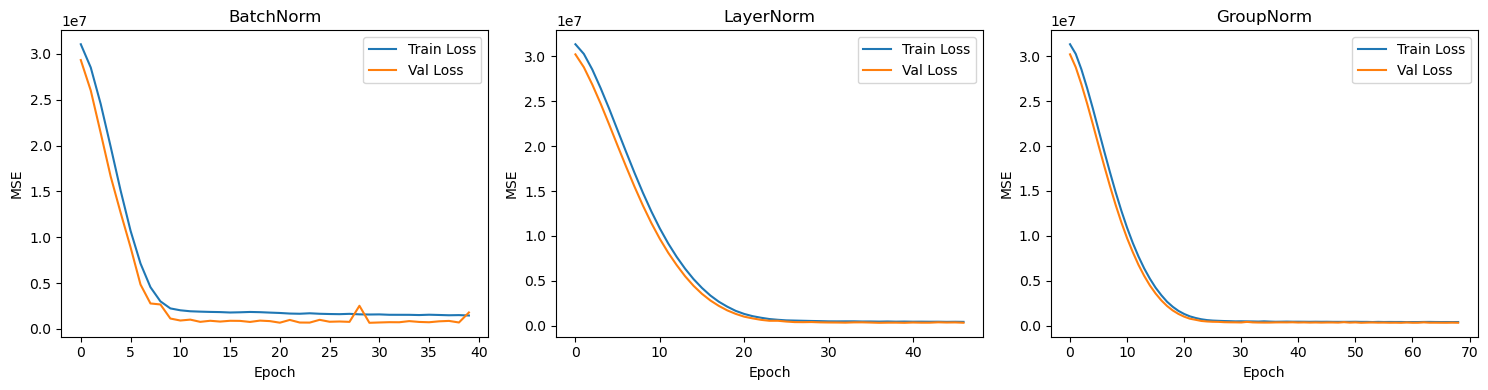

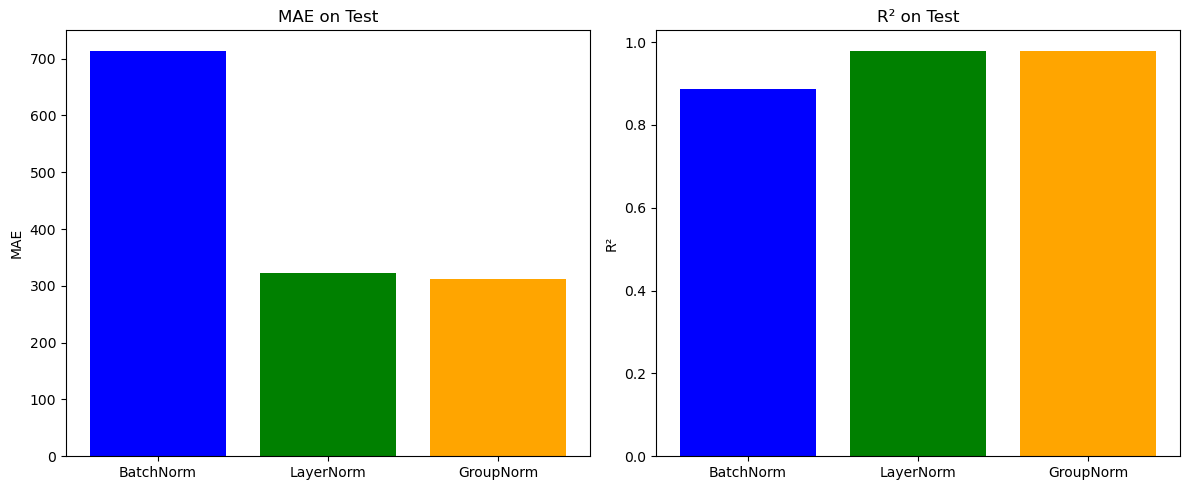

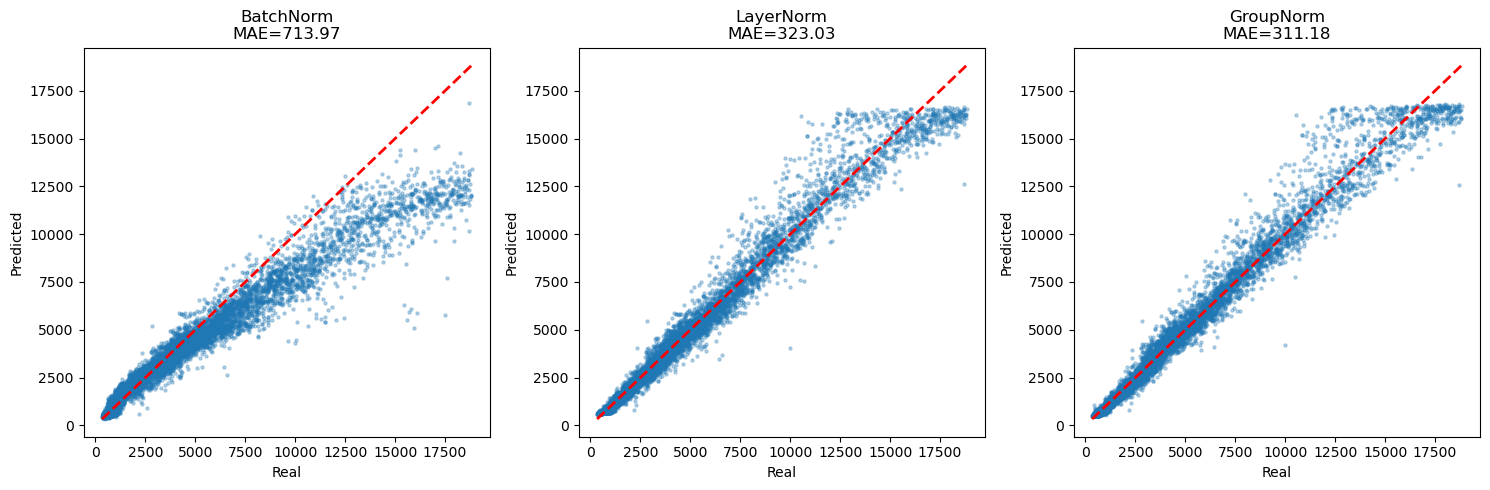

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (train_loss, val_loss, _)) in zip(axes, histories.items()):
    ax.plot(train_loss, label='Train Loss')
    ax.plot(val_loss, label='Val Loss')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
names = list(final_maes.keys())
mae_vals = [final_maes[n] for n in names]
r2_vals = [final_r2s[n] for n in names]

ax1.bar(names, mae_vals, color=['blue', 'green', 'orange'])
ax1.set_title('MAE on Test')
ax1.set_ylabel('MAE')
ax2.bar(names, r2_vals, color=['blue', 'green', 'orange'])
ax2.set_title('R² on Test')
ax2.set_ylabel('R²')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, model) in zip(axes, models.items()):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            preds.append(model(batch_X).numpy())
    y_pred = np.concatenate(preds).flatten()
    ax.scatter(y_test_t.numpy().flatten(), y_pred, alpha=0.3, s=5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_title(f'{name}\nMAE={final_maes[name]:.2f}')
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicted')
plt.tight_layout()
plt.show()

In [20]:
class DiamondPipeline:
    def __init__(self, model, scaler, label_encoders, feature_names, categorical_cols):
        self.model = model
        self.scaler = scaler
        self.label_encoders = label_encoders
        self.feature_names = feature_names
        self.categorical_cols = categorical_cols
        self.model.eval()

    def preprocess(self, df):
        data = df.copy()
        for col in self.categorical_cols:
            data[col] = self.label_encoders[col].transform(data[col])
        X = data[self.feature_names]
        X_scaled = self.scaler.transform(X).astype(np.float32)
        return torch.tensor(X_scaled)

    def predict(self, df):
        with torch.no_grad():
            X_tensor = self.preprocess(df)
            pred = self.model(X_tensor).numpy().flatten()
        return pred

In [21]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df[col])
    label_encoders[col] = le

feature_names = X_train.columns.tolist()

best_model = models['BatchNorm']

pipeline = DiamondPipeline(
    model=best_model,
    scaler=scaler,
    label_encoders=label_encoders,
    feature_names=feature_names,
    categorical_cols=categorical_cols
)

sample_raw = X_test.iloc[:5]
preds = pipeline.predict(sample_raw)
print("Предсказания для sample:", preds)

print("Реальные цены:", y_test.iloc[:5].values)

Предсказания для sample: [ 661.14386 2280.2634  1236.6733  1480.2673  8384.809  ]
Реальные цены: [ 559 2201 1238 1304 6901]
